In [1]:
from utils import *
NOTEBOOK_ID = '10'

In [2]:
data_df = pd.read_csv(f'{ANALYSIS_DIR}/experimental_data_fitted.csv')
control_df = pd.read_csv(f'{LIBRARY_DIR}/viral_controls.csv')
tax_df = pd.read_csv(f'{ANALYSIS_DIR}/tax_counts_merged.csv')
merged_df = data_df.merge(tax_df[['tax_id','family']],on='tax_id')
grouped = merged_df.groupby(['family', 'is_activator'])['tile_ID'].count().reset_index()
grouped = grouped.rename(columns={'tile_ID': 'count'})
grouped['normalized_count'] = grouped.groupby('family')['count'].transform(lambda x: x / x.sum())
grouped['family'] = grouped['family'].replace({'Family not found':'Incertae sedis'})
pivot_df = grouped.pivot(index='family', columns='is_activator', values='normalized_count').fillna(0)

In [ ]:
data_df = pd.read_csv(f'{ANALYSIS_DIR}/experimental_data_fitted.csv')
data_df['is_control'] = data_df['tile_ID'].isin(control_df['tile_ID'])
paddle_df = pd.read_csv(f'{INFERENCE_DIR}/01-PADDLE/PADDLE_predictions.csv')
data_df = paddle_df.drop(columns='tile_ID').merge(data_df,on='tile',how='outer',indicator=True).query('_merge != "left_only"')
synthesis_df = pd.concat([
    pd.read_csv(f'{LIBRARY_DIR}/eLW044-fLW132.csv'),
    pd.read_csv(f'{LIBRARY_DIR}/eLW044-fLW133.csv'),
    pd.read_csv(f'{LIBRARY_DIR}/eLW044-fLW134_twist_order.csv'),
    pd.read_csv(f'{LIBRARY_DIR}/eLW044-fLW135_twist_order.csv'),
]).drop_duplicates(subset=['tile_ID']).reset_index(drop=True).drop(columns=['library_ID','na_seq+overhangs'])
data_df = data_df.merge(synthesis_df,on='tile_ID')
data_df = data_df.rename(columns={'protein_id':'protein_ID','tax_id':'taxonomy_ID','tile':'AA_seq','ncbi_id':'RefSeq_ID','zscore':'PADDLE_zscore','na_seq':'DNA_seq'})#.drop(columns=['log_cov_rep1','log_cov_rep2','ratio_rep3','coverage_rep3','log_cov_rep3'])
data_df.loc[data_df['is_control'] == True,'taxonomy_ID'] = np.nan
data_df.loc[data_df['is_control'] == True,'RefSeq_ID'] = np.nan
data_df.loc[data_df['is_control'] == True,'taxonomy_ID'] = np.nan
data_df.loc[data_df['is_control'] == True,'taxonomy_ID'] = np.nan
data_df = data_df[['dataset','is_control','is_activator','RefSeq_ID','taxonomy_ID','protein_ID','tile_ID','AA_seq','PADDLE_zscore','ratio_rep1', 'coverage_rep1', 'ratio_rep2', 'coverage_rep2']]#.sort_values('dataset')
data_df['dataset']=pd.Categorical(data_df['dataset'],categories=['250', '500', '1K','2K'])
data_df = data_df.sort_values('dataset')
data_df.to_csv(f'{ANALYSIS_DIR}/experimental_data.csv',index=False)
data_df.head()

,dataset,is_control,is_activator,RefSeq_ID,taxonomy_ID,protein_ID,tile_ID,AA_seq,PADDLE_zscore,ratio_rep1,coverage_rep1,ratio_rep2,coverage_rep2
1989,250,False,False,NC_028949,1777016.0,AVT81_gp1,AVT81_gp1-348,AQSHNDKNAYARMCDKTHKLLCDTTANNAGLMEDYIESTTLEWLTE...,5.764130,0.822308,0.000088,0.705999,0.000096
2644,250,False,False,NC_010305,12194.0,LNRSV_gp1,LNRSV_gp1-074,DDEAIFETGESIYTVNVEGEADFGFKCNGETWFHLQKAQGFEMPKG...,5.357144,0.917818,0.000387,0.949513,0.000308
1314,250,False,True,NC_006948,394036.0,MVX_gp2,MVX_gp2-004,IRHAPFPTAITGGTPDPPHISGQRITAPPGPANIVDEYPLVDWAGA...,5.005658,0.947870,0.000492,1.179637,0.000471
1469,250,False,True,NC_055600,3051985.0,KM756_gp1,KM756_gp1-303,PMVRGKSVVNLDHLLVYTPKQTDMYNTRATQAQFDSWYDGVKMDYG...,5.173529,0.961897,0.000557,1.029614,0.000490
3494,250,True,False,NaN,NaN,NaN,B9,DNNPFQSNRSGLNPAQQMGLTRDFLGVSNEHHPHQTGRRPFLPQEL...,NaN,0.764889,0.017782,0.828108,0.018377


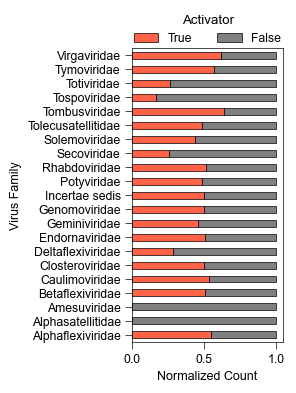

In [4]:
ax = pivot_df.iloc[:,::-1].plot(kind='barh', stacked=True, figsize=(3,4),color=['tomato','grey'])
for patch in ax.patches:
    patch.set_linewidth(0.5)
    patch.set_edgecolor('black')
plt.ylabel('Virus Family')
plt.xlabel('Normalized Count')
plt.legend(frameon=False,title='Activator', labels=['True','False'])
sns.move_legend(ax, "lower center",bbox_to_anchor=(.5, 0.975), ncol=2)
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-library_identified_activators.svg',**FIG_PARAMS)